In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [2]:
pred_500 = pd.read_csv("/scratch/st-cdeboer-1/sambina/mpra_position_paper/figure_2/human_motifs/output/predicted_k562_regulator_knockout.csv")

In [3]:
pred_500['allele'] = pred_500['motif_name'].str.extract(r"_(ref|alt)")
pred_500['motif_group'] = pred_500['motif_name'].str.replace(r'_alt$', '', regex=True)
merged_df_ref = pred_500[pred_500['allele'] != 'alt'].copy()
merged_df_alt = pred_500[pred_500['allele'] == 'alt'].copy()


merged_df_ref = merged_df_ref.rename(columns={col: f"ref_{col}" for col in merged_df_ref.columns if col not in ['seq_id', 'motif_group', 'motif_name']})
merged_df_alt = merged_df_alt.rename(columns={col: f"alt_{col}" for col in merged_df_alt.columns if col not in ['seq_id', 'motif_group', 'motif_name']})

merged_df = pd.merge(merged_df_ref, merged_df_alt, on=['seq_id', 'motif_group'], how='inner')

offsets=range(-80,81)

# Compute diff_offset for each offset
for offset in offsets:
    merged_df[f'diff_{offset}'] =  merged_df[f'ref_predicted_{offset}'] - merged_df[f'alt_predicted_{offset}']

avg_diff = merged_df.groupby('motif_group')[[f'diff_{offset}' for offset in offsets]].mean().reset_index()


/tmp/ipykernel_717041/3955159958.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df[f'diff_{offset}'] =  merged_df[f'ref_predicted_{offset}'] - merged_df[f'alt_predicted_{offset}']
/tmp/ipykernel_717041/3955159958.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df[f'diff_{offset}'] =  merged_df[f'ref_predicted_{offset}'] - merged_df[f'alt_predicted_{offset}']
/tmp/ipykernel_717041/3955159958.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` ma

In [4]:
# Update column names based on the value after diff_
updated_columns = []

for col in avg_diff.columns:
    if col.startswith("diff_"):  # Check if the column name starts with "diff_"
        value = int(col.split("_")[1])  # Extract the value after diff_
        if value < 0:
            updated_columns.append(f"{abs(value)}bp right")  # Append "right" for negative values
        elif value > 0:
            updated_columns.append(f"{value}bp left")  # Append "left" for positive values
        else:
            updated_columns.append(f"center")  # Append "center" for zero values
    else:
        updated_columns.append(col)  # Keep the motif_group column unchanged

# Assign the new column names back to the DataFrame
avg_diff.columns = updated_columns

# Print the updated column names to check
print(avg_diff.columns)


Index(['motif_group', '80bp right', '79bp right', '78bp right', '77bp right',
       '76bp right', '75bp right', '74bp right', '73bp right', '72bp right',
       ...
       '71bp left', '72bp left', '73bp left', '74bp left', '75bp left',
       '76bp left', '77bp left', '78bp left', '79bp left', '80bp left'],
      dtype='object', length=162)


In [5]:
# Separate the columns into three lists based on their suffix
left_columns = [col for col in avg_diff.columns if 'left' in col]
center_columns = [col for col in avg_diff.columns if 'center' in col]
right_columns = [col for col in avg_diff.columns if 'right' in col]

left_bp_list = [f"{i}bp left" for i in range(80, 0, -1)]
right_bp_list = [f"{i}bp right" for i in range(1, 81, 1)]

# Concatenate the columns in the desired order (left, center, right)
new_column_order = ['motif_group'] + left_bp_list + center_columns + right_bp_list
# Rearrange the columns in the DataFrame
avg_diff = avg_diff[new_column_order]

# Print the updated column order to verify
print(avg_diff.columns)


Index(['motif_group', '80bp left', '79bp left', '78bp left', '77bp left',
       '76bp left', '75bp left', '74bp left', '73bp left', '72bp left',
       ...
       '71bp right', '72bp right', '73bp right', '74bp right', '75bp right',
       '76bp right', '77bp right', '78bp right', '79bp right', '80bp right'],
      dtype='object', length=162)


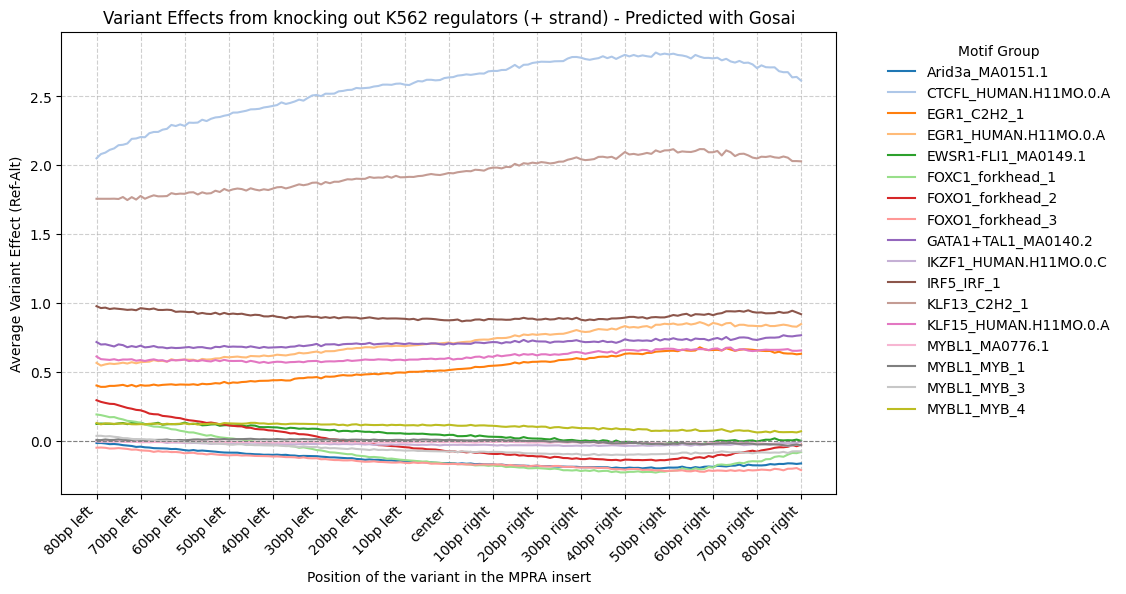

In [6]:
# Filter out Mouse-related motif groups
avg_diff = avg_diff[~avg_diff['motif_group'].str.contains("Mouse", case=False, na=False)]

offsets = range(-80,81)
mapped_offsets = offsets  # No transformation applied

# Generate distinct colors
num_motifs = avg_diff.shape[0]
colormap = plt.get_cmap("tab20")  # Use plt.get_cmap instead of cm.get_cmap
colors = [colormap(i % 20) for i in range(num_motifs)]  # Ensure we don't exceed 20 colors

# Plot
plt.figure(figsize=(10, 6))

x_labels = avg_diff.columns[1:]  # Skip 'motif_group'
x_vals = range(len(x_labels))    # Use their index positions for plotting

for idx, (_, row) in enumerate(avg_diff.iterrows()):
    y_vals = row[1:]  
    plt.plot(x_vals, y_vals, label=row['motif_group'], color=colors[idx])

# Formatting
plt.xlabel("Position of the variant in the MPRA insert")
plt.ylabel("Average Variant Effect (Ref-Alt)")
tick_indices = list(range(0, len(x_labels), 10))
tick_labels = [x_labels[i] for i in tick_indices]
plt.xticks(ticks=tick_indices, labels=tick_labels, rotation=45, ha="right")

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)  # Add horizontal reference line
plt.legend(title="Motif Group", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)
plt.title("Variant Effects from knocking out K562 regulators (+ strand) - Predicted with Gosai")
plt.savefig("/scratch/st-cdeboer-1/sambina/mpra_position_paper/figure_2/human_motifs/output/knockout.svg", format="svg")

# Show plot
plt.show()
